In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import numpy as np

# Load your data (replace with your actual AnnData object)
raw_ad_annot = ad.read_h5ad("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/ctnnd2_scrnaseq_raw_annotated_with_astro_glu_intn_oligo_251103.h5ad")
adata_scvi = sc.read_h5ad("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/p28_scvi_240110.h5ad")
adata = sc.read_h5ad("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/ctnnd2_scrnaseq_annotated_raw_250107.h5ad")

In [16]:
np.sum(raw_ad_annot.X)

np.float32(611539650.0)

In [5]:
adata_scvi.obs['ProcessBatch'].unique()

['Batch5', 'Batch6']
Categories (2, object): ['Batch5', 'Batch6']

In [8]:
adata_clusters = sc.read_h5ad("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/ctnnd2_scrnaseq_clusters_241219.h5ad")

adata.obsm["X_pca"] = adata_clusters.obsm["X_pca"]
adata.obsm["X_umap"] = adata_clusters.obsm["X_umap"]
adata.obs["leiden_res_0.25"] = adata_clusters.obs["leiden_res_0.25"]
adata.obs["leiden_res_0.10"] = adata_clusters.obs["leiden_res_0.10"]

In [20]:
raw_ad_annot.obsm["X_pca"] = adata_scvi.obsm["X_pca"]
raw_ad_annot.obsm["X_umap"] = adata_scvi.obsm["X_umap"]
raw_ad_annot.obsm["X_scVI"] = adata_scvi.obsm["X_scVI"]
raw_ad_annot.obs["_scvi_batch"] = adata_scvi.obs["_scvi_batch"]

In [30]:
np.sum(adata_scvi.layers['counts'])

np.float32(22002572.0)

In [26]:
adata_scvi.write("Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/GEO_submission/ctnnd2_scrnaseq_batch_corrected_finalannot.h5ad")
adata.write("Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/GEO_submission/ctnnd2_scrnaseq_uncorrected_initialannot.h5ad")
raw_ad_annot.write("Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 3/GEO_submission/ctnnd2_scrnaseq_uncorrected_finalannot.h5ad")

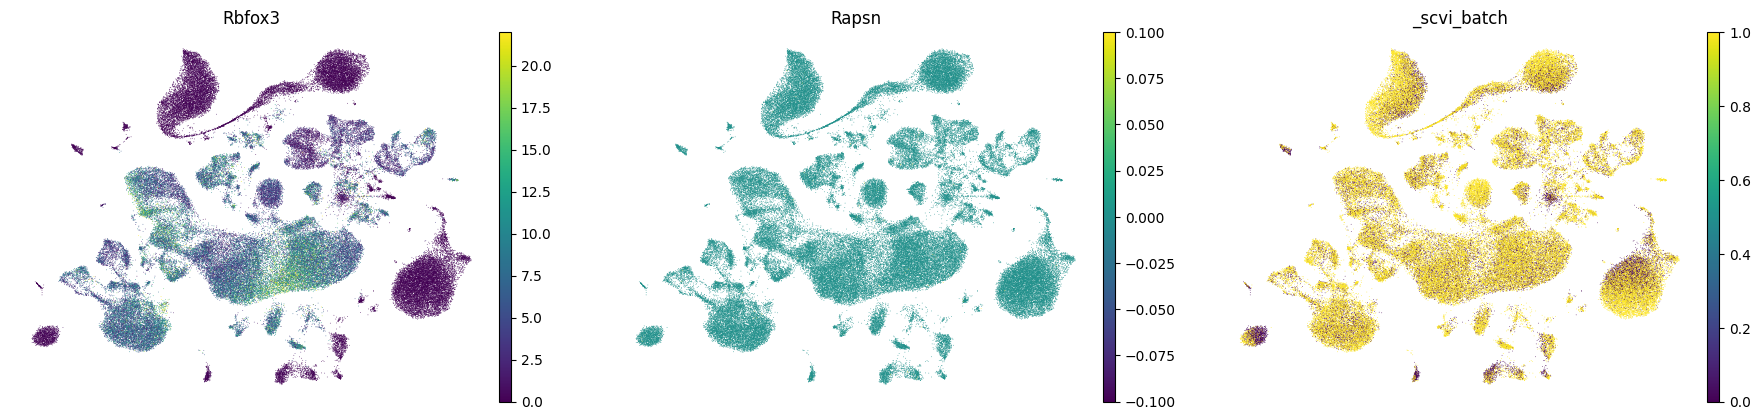

In [24]:
sc.pl.umap(
    raw_ad_annot,
    color=['Rbfox3', 'Rapsn', '_scvi_batch'],
    vmin=0,
    vmax="p99",  # set vmax to the 99th percentile of the gene count instead of the maximum, to prevent outliers from making expression in other cells invisible. Note that this can cause problems for extremely lowly expressed genes.
    sort_order=False,  # do not plot highest expression on top, to not get a biased view of the mean expression among cells
    frameon=False,
    cmap="viridis",  # or choose another color map e.g. from here: https://matplotlib.org/stable/tutorials/colors/colormaps.html
)

In [5]:
raw_ad_annot.obs

,group,sample_id,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,cluster_id
AAAAAAAAAGTCTGTC-0,KO,KO2,0,3088,8.035603,9744.0,9.184509,14.275452,1.0,0.693147,0.010263,14.0,2.708050,0.143678,1.0,0.693147,0.010263,False,False,L6
AAAAAAAACCAACTTA-0,KO,KO2,0,928,6.834109,1337.0,7.198931,10.919970,0.0,0.000000,0.000000,4.0,1.609438,0.299177,0.0,0.000000,0.000000,False,False,EC
AAAAAAAACGGATTAG-0,KO,KO2,0,1477,7.298445,2881.0,7.966240,15.966678,0.0,0.000000,0.000000,7.0,2.079442,0.242971,1.0,0.693147,0.034710,False,False,OPC
AAAAAAAAGAACTGAC-0,KO,KO2,0,2234,7.711997,4680.0,8.451267,12.243590,2.0,1.098612,0.042735,9.0,2.302585,0.192308,1.0,0.693147,0.021368,False,False,PV
AAAAAAAAGAGGTGGG-0,KO,KO2,0,2820,7.944847,7780.0,8.959440,13.431877,2.0,1.098612,0.025707,4.0,1.609438,0.051414,0.0,0.000000,0.000000,False,False,L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AACCAAAGAGGCGGCA-5,WT,WT4,5,3243,8.084562,8818.0,9.084663,13.064187,6.0,1.945910,0.068043,20.0,3.044523,0.226809,0.0,0.000000,0.000000,False,False,L2_3
AACCAAAGCATCGTAC-5,WT,WT4,5,1837,7.516433,2973.0,7.997663,8.879919,1.0,0.693147,0.033636,7.0,2.079442,0.235452,0.0,0.000000,0.000000,False,False,VLMC
AACCAAAGCCAGAAAC-5,WT,WT4,5,1049,6.956545,1788.0,7.489412,15.883669,0.0,0.000000,0.000000,1.0,0.693147,0.055928,0.0,0.000000,0.000000,False,False,L2_3
AACCAAAGCCATTAAG-5,WT,WT4,5,4109,8.321178,13854.0,9.536402,13.375198,4.0,1.609438,0.028873,28.0,3.367296,0.202108,0.0,0.000000,0.000000,False,False,L2_3


C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


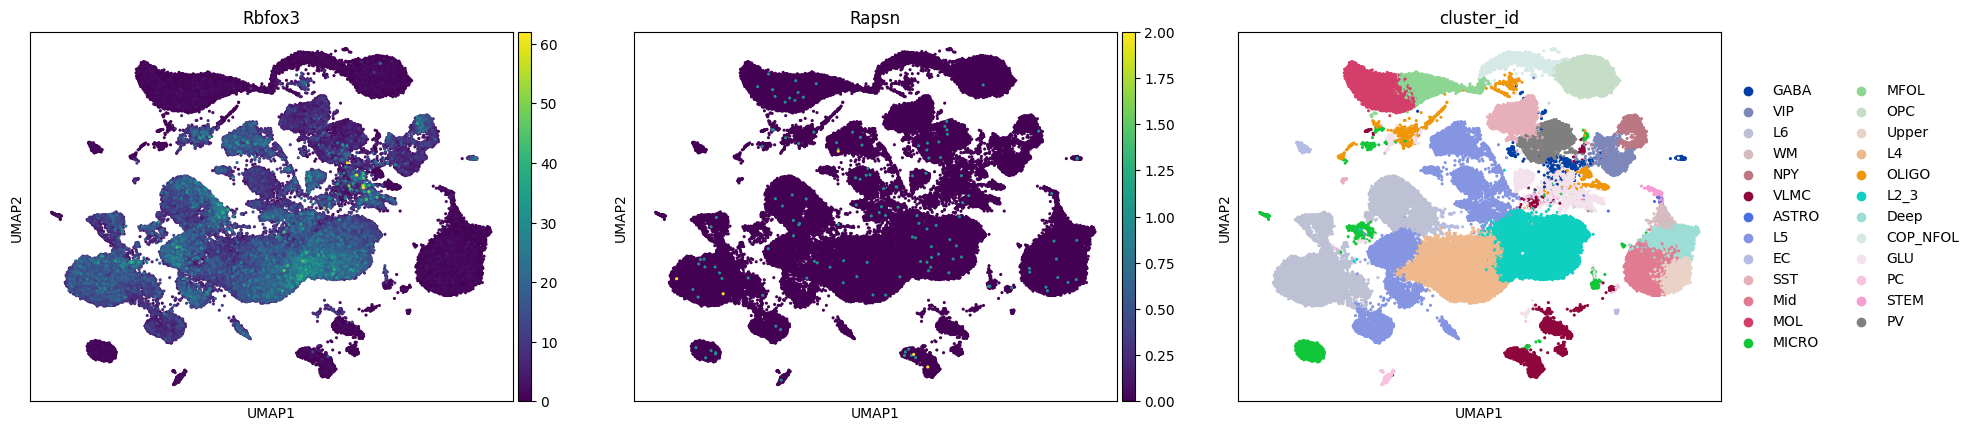

In [6]:
# Ensure you have UMAP/tSNE computed (optional, but common)
sc.pp.neighbors(raw_ad_annot, use_rep='X_scVI')
sc.tl.umap(raw_ad_annot)

# Plotting two genes on a UMAP embedding
sc.pl.umap(raw_ad_annot, color=['Rbfox3', 'Rapsn', 'cluster_id'], cmap='viridis', size=20) # Shows color for each gene


In [7]:
adata.obs

,group,sample_id,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,...,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,cluster_id,leiden_res_0.25,leiden_res_0.10
AAAAAAAAAGTCTGTC-0,KO,KO2,0,3088,8.035603,9744.0,9.184509,14.275452,1.0,0.693147,...,2.708050,0.143678,1.0,0.693147,0.010263,False,False,GLU,7,3
AAAAAAAACCAACTTA-0,KO,KO2,0,928,6.834109,1337.0,7.198931,10.919970,0.0,0.000000,...,1.609438,0.299177,0.0,0.000000,0.000000,False,False,EC,21,16
AAAAAAAACGGATTAG-0,KO,KO2,0,1477,7.298445,2881.0,7.966240,15.966678,0.0,0.000000,...,2.079442,0.242971,1.0,0.693147,0.034710,False,False,OLIGO,5,5
AAAAAAAAGAACTGAC-0,KO,KO2,0,2234,7.711997,4680.0,8.451267,12.243590,2.0,1.098612,...,2.302585,0.192308,1.0,0.693147,0.021368,False,False,GABA,6,6
AAAAAAAAGAGGTGGG-0,KO,KO2,0,2820,7.944847,7780.0,8.959440,13.431877,2.0,1.098612,...,1.609438,0.051414,0.0,0.000000,0.000000,False,False,GLU,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AACCAAAGAGGCGGCA-5,WT,WT4,5,3243,8.084562,8818.0,9.084663,13.064187,6.0,1.945910,...,3.044523,0.226809,0.0,0.000000,0.000000,False,False,GLU,0,0
AACCAAAGCATCGTAC-5,WT,WT4,5,1837,7.516433,2973.0,7.997663,8.879919,1.0,0.693147,...,2.079442,0.235452,0.0,0.000000,0.000000,False,False,VLMC,17,14
AACCAAAGCCAGAAAC-5,WT,WT4,5,1049,6.956545,1788.0,7.489412,15.883669,0.0,0.000000,...,0.693147,0.055928,0.0,0.000000,0.000000,False,False,GLU,0,0
AACCAAAGCCATTAAG-5,WT,WT4,5,4109,8.321178,13854.0,9.536402,13.375198,4.0,1.609438,...,3.367296,0.202108,0.0,0.000000,0.000000,False,False,GLU,0,0


<Figure size 600x600 with 0 Axes>

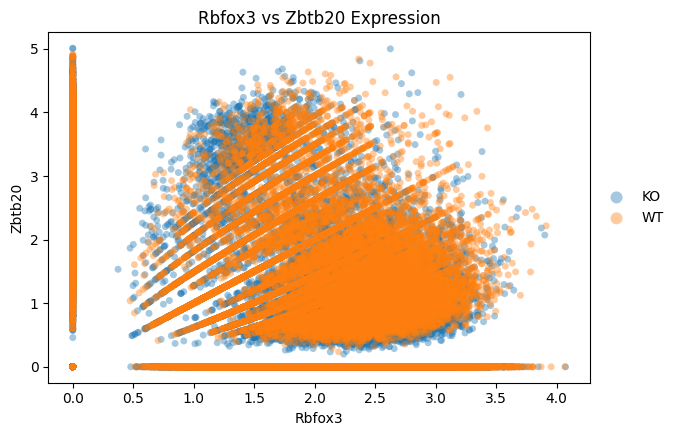

In [8]:
plt.figure(figsize=(6, 6))
sc.pl.scatter(adata_scvi, x='Rbfox3', y='Zbtb20', color='condition', # or another obs/var column
              size = 100, 
              show=False, 
              alpha = 0.4)
plt.title("Rbfox3 vs Zbtb20 Expression")
plt.show()

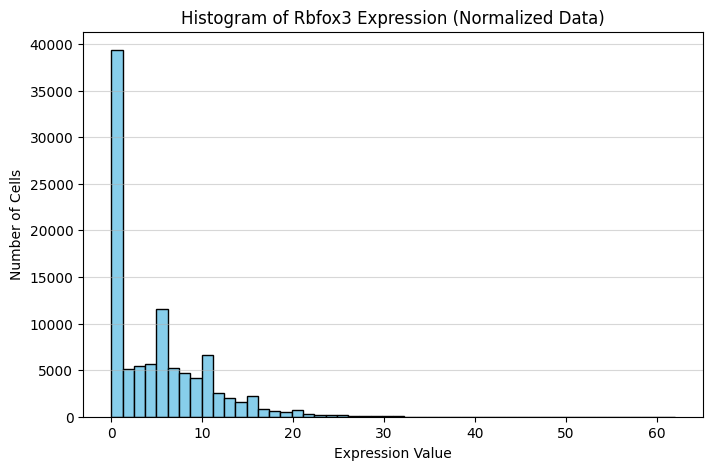

In [10]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'adata' is your loaded AnnData object
# e.g., adata = sc.read_h5ad("my_data.h5ad")

# Define the gene you want to visualize
gene_name = "Rbfox3" # Example gene name, replace with your gene of interest

# Check if the gene exists in the AnnData object's variable names
if gene_name in raw_ad_annot.var_names:
    # Extract the expression data for the specific gene
    # The .X matrix might be sparse, so convert to array using .toarray() if necessary
    # Check if using normalized data or raw counts
    
    # If you have raw counts stored in .raw
    if raw_ad_annot.raw is not None and gene_name in raw_ad_annot.raw.var_names:
        gene_expression = raw_ad_annot.raw[:, gene_name].X.toarray().flatten()
        data_source = "Raw Counts"
    # Otherwise use the main .X matrix (e.g., normalized/scaled data)
    else:
        gene_expression = adata[:, gene_name].X.toarray().flatten()
        data_source = "Normalized Data"
    
    # Create the histogram
    plt.figure(figsize=(8, 5))
    plt.hist(gene_expression, bins=50, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {gene_name} Expression ({data_source})')
    plt.xlabel('Expression Value')
    plt.ylabel('Number of Cells')
    plt.grid(True, axis='y', alpha=0.5)
    plt.show()

else:
    print(f"Gene '{gene_name}' not found in raw_ad_annot.var_names or raw_ad_annot.raw.var_names.")



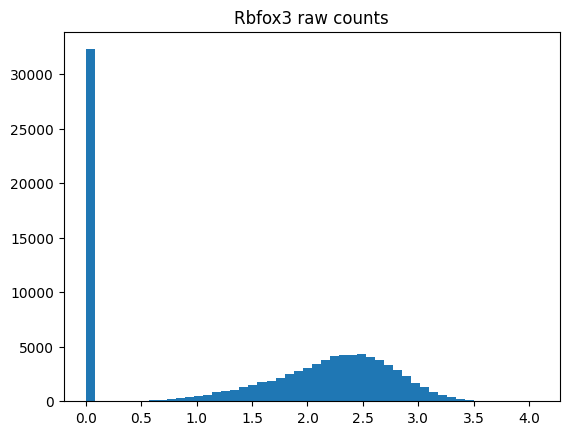

In [11]:
gene_expression = adata_clusters.raw[:, "Rbfox3"].X

if hasattr(gene_expression, "toarray"):
    gene_expression = gene_expression.toarray().flatten()

plt.hist(gene_expression, bins=50)
plt.title("Rbfox3 raw counts")
plt.show()


In [45]:
import anndata as ad
import numpy as np

# 1. Create a boolean mask
# Get the expression values for 'GeneA' across all cells
rbfox3_expr = adata_clusters.raw[:, 'Rbfox3'].X.toarray().ravel()

# nonzero thresholds
rbfox3_thr = 0.5

# high / low relative to expressing median
rbfox3_hi = rbfox3_expr > rbfox3_thr
rbfox3_lo = rbfox3_expr <= rbfox3_thr

# 2. Apply the mask to subset the AnnData object
# The first colon selects all variables, the mask selects the observations (cells)
neun_pos = adata_clusters[rbfox3_hi, :].copy()
neun_neg = adata_clusters[rbfox3_lo, :].copy()

# print the number of cells before and after subsetting
print(f"Original number of cells: {adata.n_obs}")
print(f"Number of NeuN+ cells: {neun_pos.n_obs}")
print(f"Number of NeuN- cells: {neun_neg.n_obs}")

# Create categorical labels
adata_clusters.obs["neun_status"] = np.where(
    rbfox3_expr > rbfox3_thr,
    "neun_pos",
    "neun_neg"
)

# Optional: make it categorical (nice for plotting)
adata_clusters.obs["neun_status"] = adata_clusters.obs["neun_status"].astype("category")

Original number of cells: 99966
Number of NeuN+ cells: 67687
Number of NeuN- cells: 32279


In [46]:
import numpy as np

# Extract Rbfox3 expression from raw
rbfox3_expr = raw_ad_annot[:, "Rbfox3"].X
if hasattr(rbfox3_expr, "toarray"):
    rbfox3_expr = rbfox3_expr.toarray().ravel()
else:
    rbfox3_expr = rbfox3_expr.ravel()

# Threshold
rbfox3_thr = 0

# Create categorical labels
raw_ad_annot.obs["neun_status"] = np.where(
    rbfox3_expr > rbfox3_thr,
    "neun_pos",
    "neun_neg"
)

# Optional: make it categorical (nice for plotting)
raw_ad_annot.obs["neun_status"] = raw_ad_annot.obs["neun_status"].astype("category")


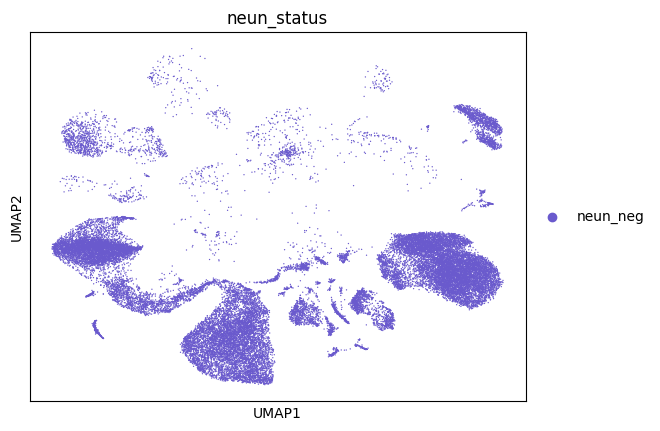

In [47]:
sc.pl.umap(neun_neg, color = ["neun_status"])

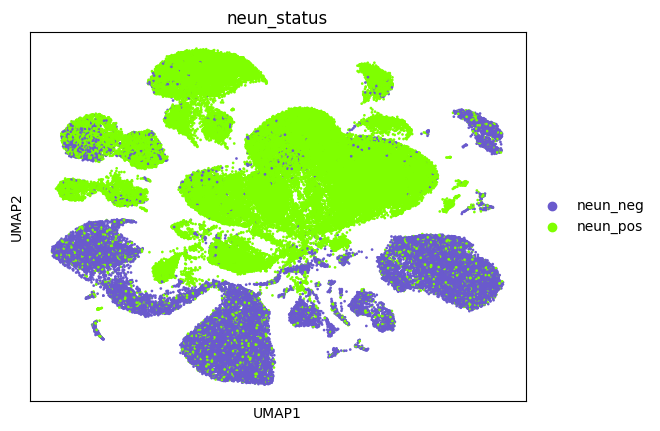

In [51]:
import scanpy as sc

sc.pl.umap(
    adata_clusters,
    color="neun_status",
    palette={"neun_pos": "chartreuse", "neun_neg": "slateblue"},
    size=15
)


In [53]:
neun_neg = raw_ad_annot[raw_ad_annot.obs["neun_status"] == "neun_neg"].copy()
print(f"Original cells: {raw_ad_annot.n_obs}")
print(f"NeuN− cells: {neun_neg.n_obs}")

Original cells: 99966
NeuN− cells: 32271


In [55]:
sc.pp.normalize_total(neun_neg, target_sum=1e6)
sc.pp.log1p(neun_neg)

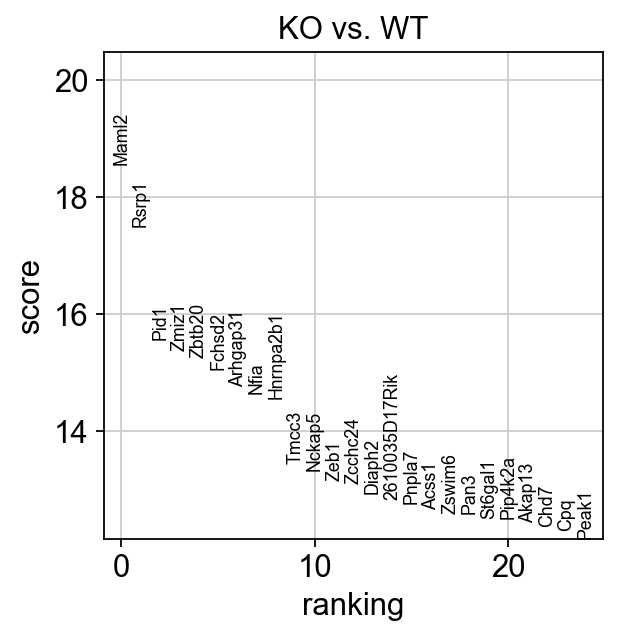

In [81]:
import pandas as pd 

sc.tl.rank_genes_groups(neun_neg, 'group', method='wilcoxon', groups=['KO'], reference='WT')
sc.pl.rank_genes_groups(neun_neg, n_genes=25, sharey=False, groups=['KO'], reference='WT', show = False)

# Save the figure with the legend outside the plot and transparent background
plt.savefig("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/rank_genes_groups_neun_neg_KO_vs_WT.png", 
            transparent=True, dpi=300, bbox_inches='tight')

result = neun_neg.uns["rank_genes_groups"]
groups = result["names"].dtype.names
grouped_results = pd.DataFrame(
    {
        group + "_" + key[:1]: result[key][group]
        for group in groups
        for key in ["names", "scores", "logfoldchanges", "pvals_adj"]
    }
)
grouped_results.to_csv('C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/neun_neg_Wilcoxon_results_260120.csv')

In [200]:
neun_neg.write("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/adata_scvi_neun_neg.h5ad")

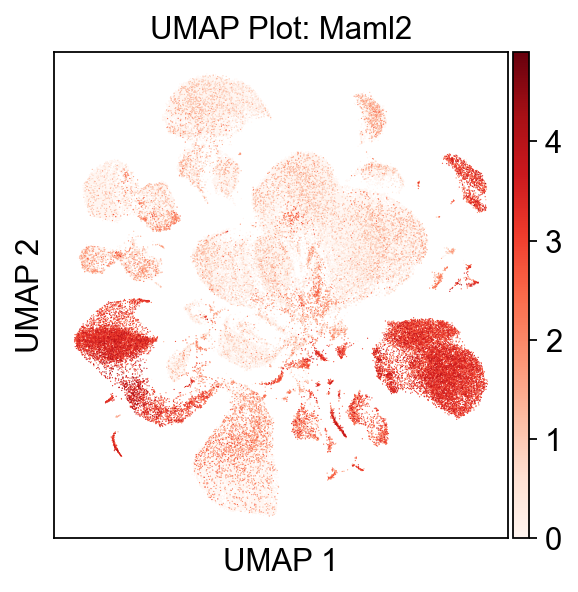

In [67]:
# Plot umap with manual annotations
# Set figure parameters
sc.set_figure_params(transparent=True)

# Plot UMAP with manual annotations, but don't show it yet
sc.pl.umap(adata_clusters, color=["Maml2"], cmap = "Reds", show=False, legend_loc='best')

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title('UMAP Plot: Maml2', color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
plt.savefig("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/umap_Maml2_black_text.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

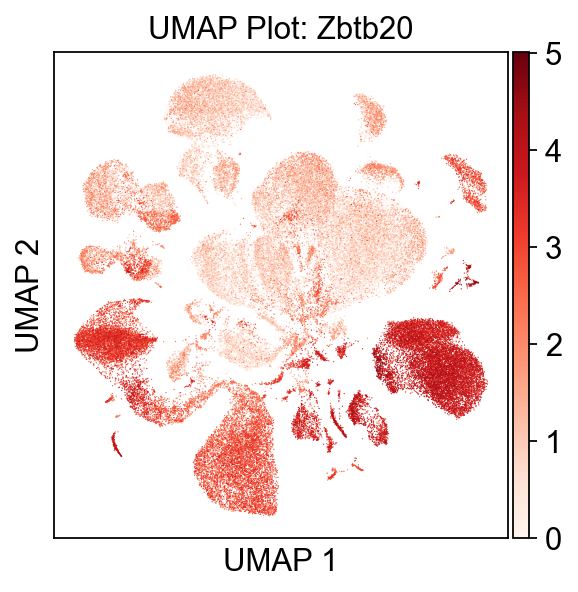

In [75]:
# Plot umap with manual annotations
# Set figure parameters
sc.set_figure_params(transparent=True)

# Plot UMAP with manual annotations, but don't show it yet
sc.pl.umap(adata_clusters, color=["Zbtb20"], cmap = "Reds", show=False, legend_loc='best')

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title('UMAP Plot: Zbtb20', color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
#plt.savefig("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/umap_Zbtb20_black_text.png", 
           # transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

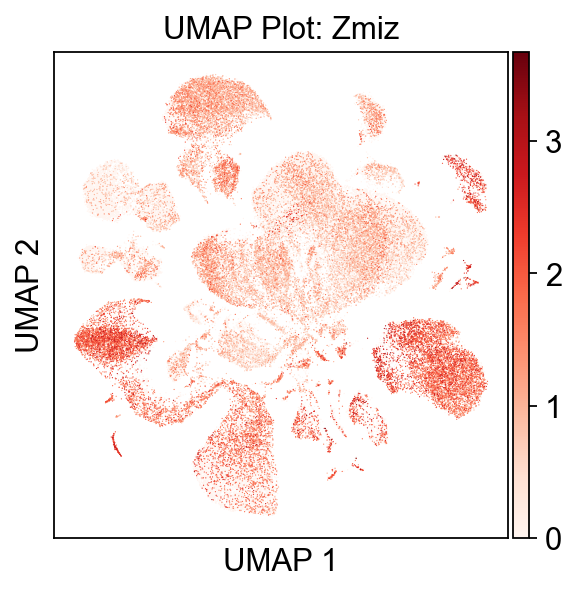

In [77]:
# Plot umap with manual annotations
# Set figure parameters
sc.set_figure_params(transparent=True)

# Plot UMAP with manual annotations, but don't show it yet
sc.pl.umap(adata_clusters, color=["Zmiz1"], cmap = "Reds", show=False, legend_loc='best')

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title('UMAP Plot: Zmiz', color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
plt.savefig("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/umap_Zmiz1_black_text.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

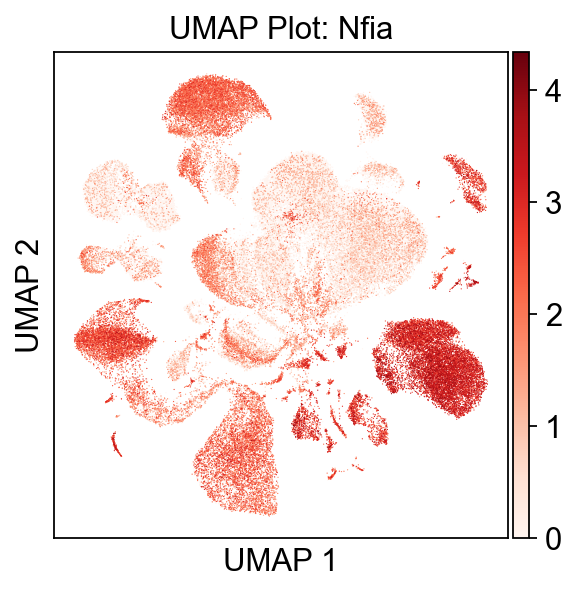

In [83]:
# Plot umap with manual annotations
# Set figure parameters
sc.set_figure_params(transparent=True)

# Plot UMAP with manual annotations, but don't show it yet
sc.pl.umap(adata_clusters, color=["Nfia"], cmap = "Reds", show=False, legend_loc='best')

# Change axis title colors to white
plt.xlabel('UMAP 1', color='black')  # Change X-axis title color to white
plt.ylabel('UMAP 2', color='black')  # Change Y-axis title color to white

# Optionally, you can also change tick label colors
plt.tick_params(axis='both', colors='black')  # Change tick label color to white

# Change the title font color
plt.title('UMAP Plot: Nfia', color='black')  # Set title color

# Save the figure with the legend outside the plot and transparent background
plt.savefig("C:/Users/Gabrielle/Documents/GitHub/ctnnd2_scrnaseq_analysis/results/umap_Nfia_black_text.png", 
            transparent=True, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()